In [2]:
import numpy as np
import plotly
import open3d as o3d
import numpy as np
import plotly.graph_objects as go

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [3]:
import os
os.getpid()

1455377

In [11]:
pcd = o3d.io.read_point_cloud("/insomnia001/home/hy2897/data/mcc/ST28_emb2_2_2026_03_30__09_54_17/24.ply")
points = np.asarray(pcd.points)
fig = go.Figure(
    go.Scatter3d(
        x=points[:, 0],
        y=points[:, 1],
        z=points[:, 2],
        mode="markers",
        marker=dict(size=2, color = points[:, 2],colorscale="viridis", opacity=0.8)
    )
)

fig.update_layout(scene_aspectmode="data")
fig.show()


In [15]:
pcd = o3d.io.read_point_cloud(
    "/insomnia001/home/hy2897/data/mcc/ST28_emb2_2_2026_03_30__09_54_17/18.ply"
)

points = np.asarray(pcd.points)

fig = go.Figure(
    go.Scatter3d(
        x=points[:, 0],
        y=points[:, 1],
        z=points[:, 2],
        mode="markers",
        marker=dict(
            size=2,
            color=points[:, 2],
            colorscale="viridis",
            opacity=0.8
        )
    )
)

fig.update_layout(
    scene=dict(
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        zaxis=dict(visible=False)
    ),
    scene_aspectmode="data"
)

fig.show()

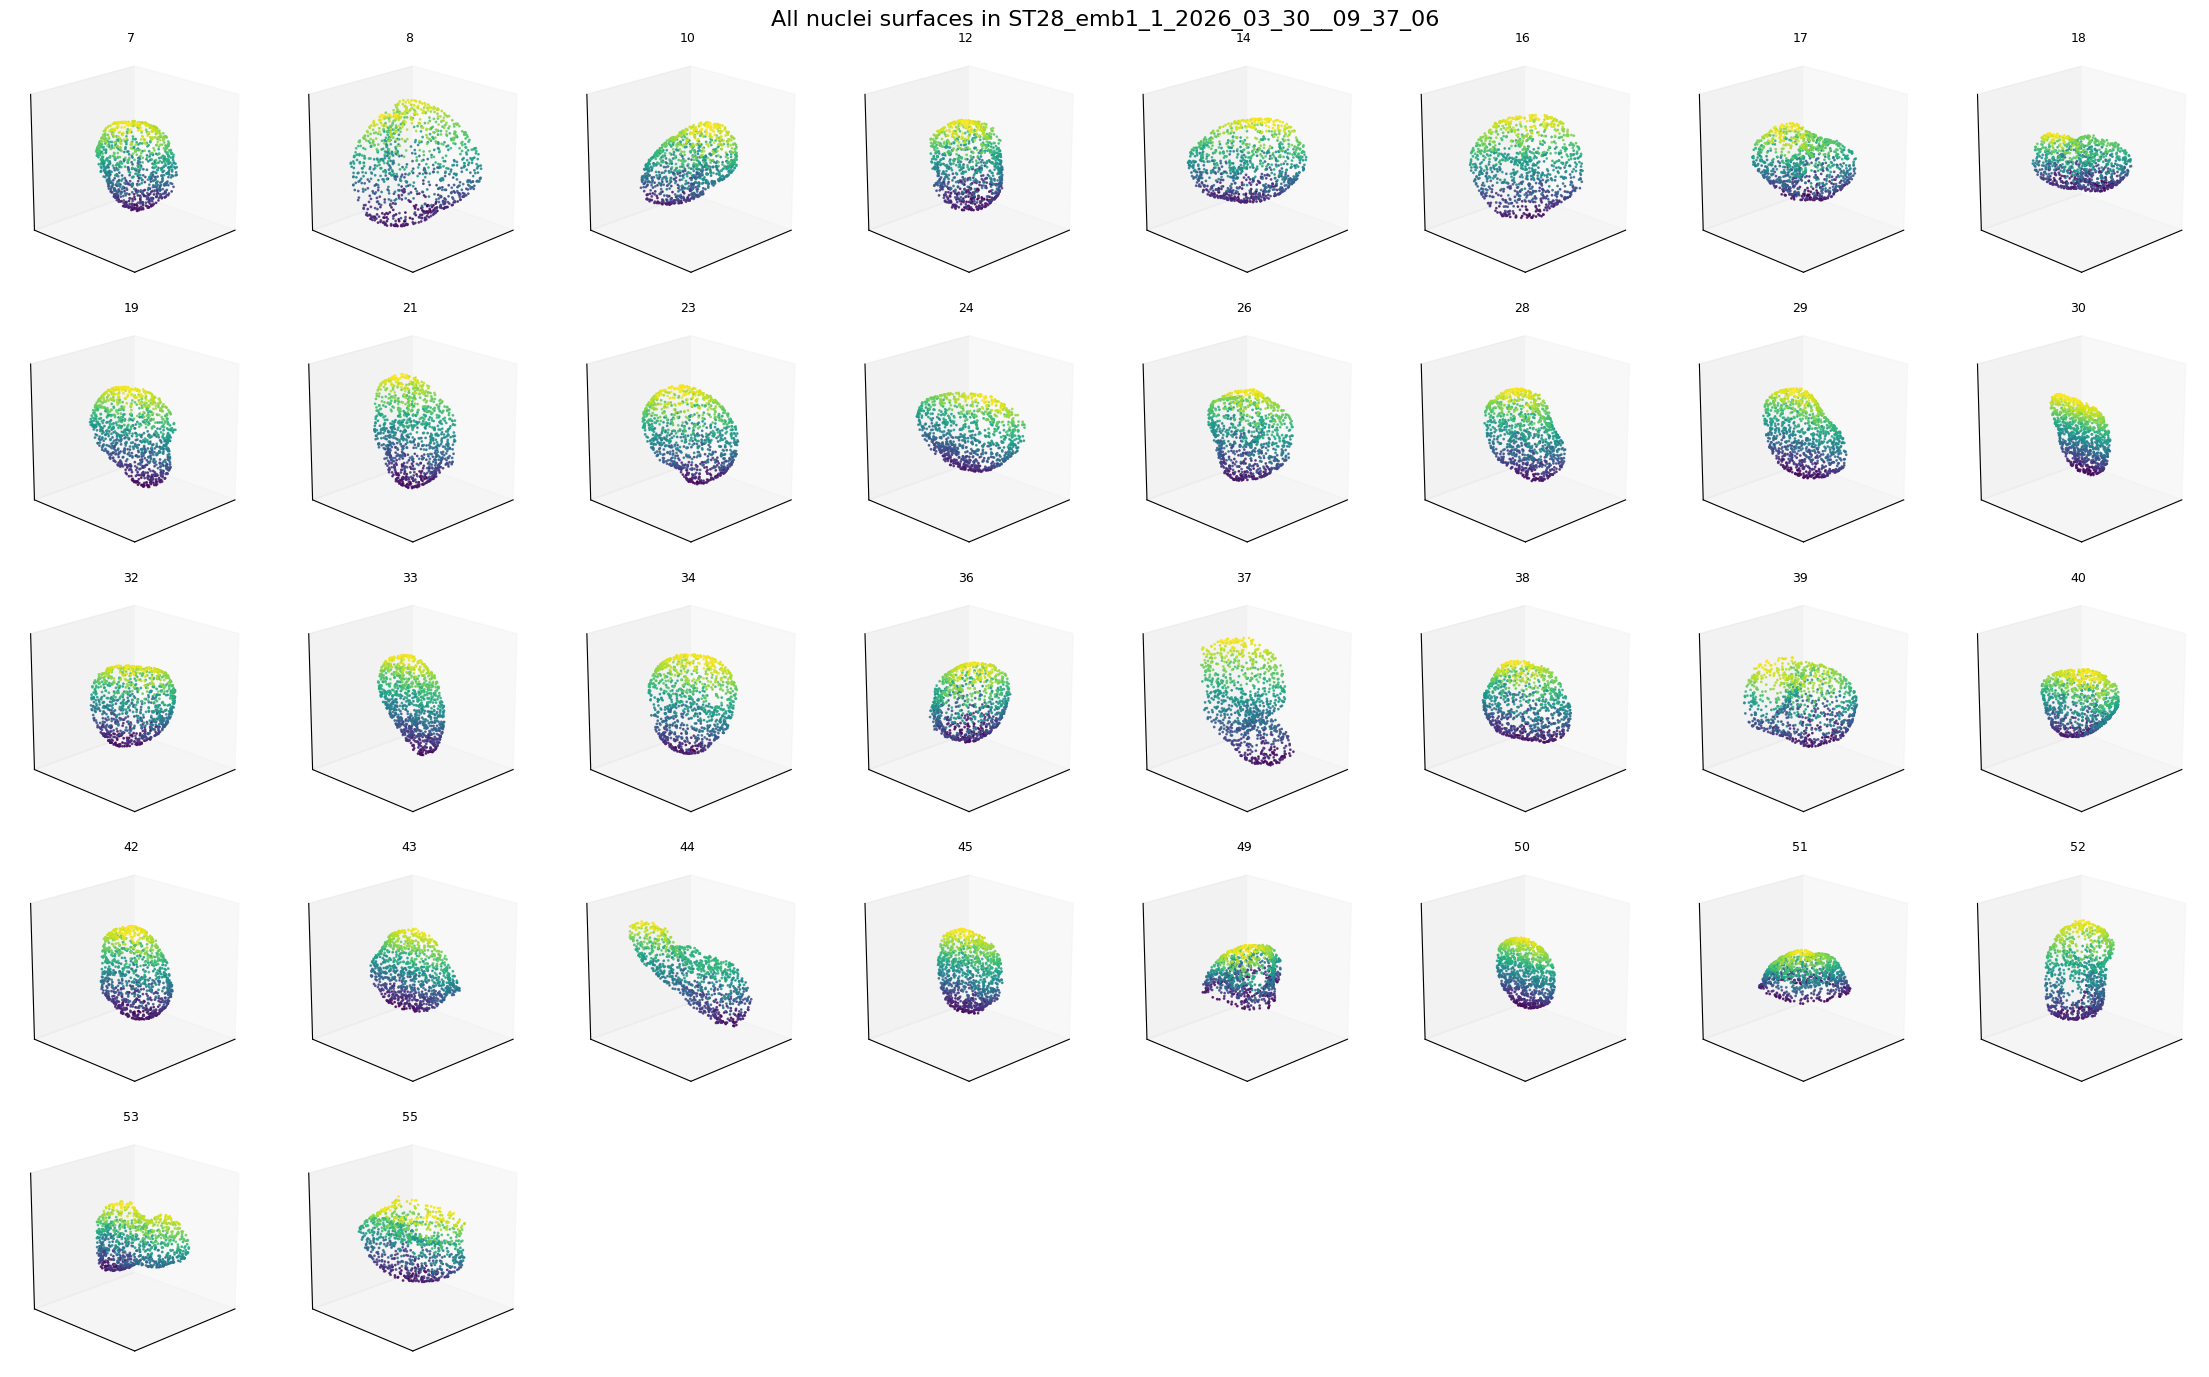

In [20]:
from pathlib import Path
import matplotlib.pyplot as plt

data_dir = Path("/insomnia001/home/hy2897/data/mcc/ST28_emb1_1_2026_03_30__09_37_06/")
ply_files = sorted(
    data_dir.glob("*.ply"),
    key=lambda path: int(path.stem) if path.stem.isdigit() else path.stem,
)

all_points = []
for ply_file in ply_files:
    pcd = o3d.io.read_point_cloud(str(ply_file))
    points = np.asarray(pcd.points)
    if points.size == 0:
        continue
    all_points.append((ply_file.stem, points))

if not all_points:
    raise ValueError(f"No valid point clouds found in {data_dir}")

n_cols = 8
n_rows = int(np.ceil(len(all_points) / n_cols))
colors = plt.cm.turbo(np.linspace(0, 1, len(all_points)))
max_extent = max(np.abs(points).max() for _, points in all_points)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(2.8 * n_cols, 2.8 * n_rows),
    subplot_kw={"projection": "3d"},
)
axes = np.atleast_2d(axes)

for ax, ((name, points), color) in zip(axes.flat, zip(all_points, colors)):
    ax.scatter(points[:, 0], points[:, 1], points[:, 2], c = points[:, 2], s=1, alpha=0.8, cmap="viridis")
    ax.set_title(name, fontsize=9, pad=2)
    ax.set_xlim(-max_extent, max_extent)
    ax.set_ylim(-max_extent, max_extent)
    ax.set_zlim(-max_extent, max_extent)
    ax.set_box_aspect((1, 1, 1))
    ax.view_init(elev=20, azim=45)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.grid(False)

for ax in axes.flat[len(all_points):]:
    ax.axis("off")

fig.suptitle(f"All nuclei surfaces in {data_dir.name}", fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

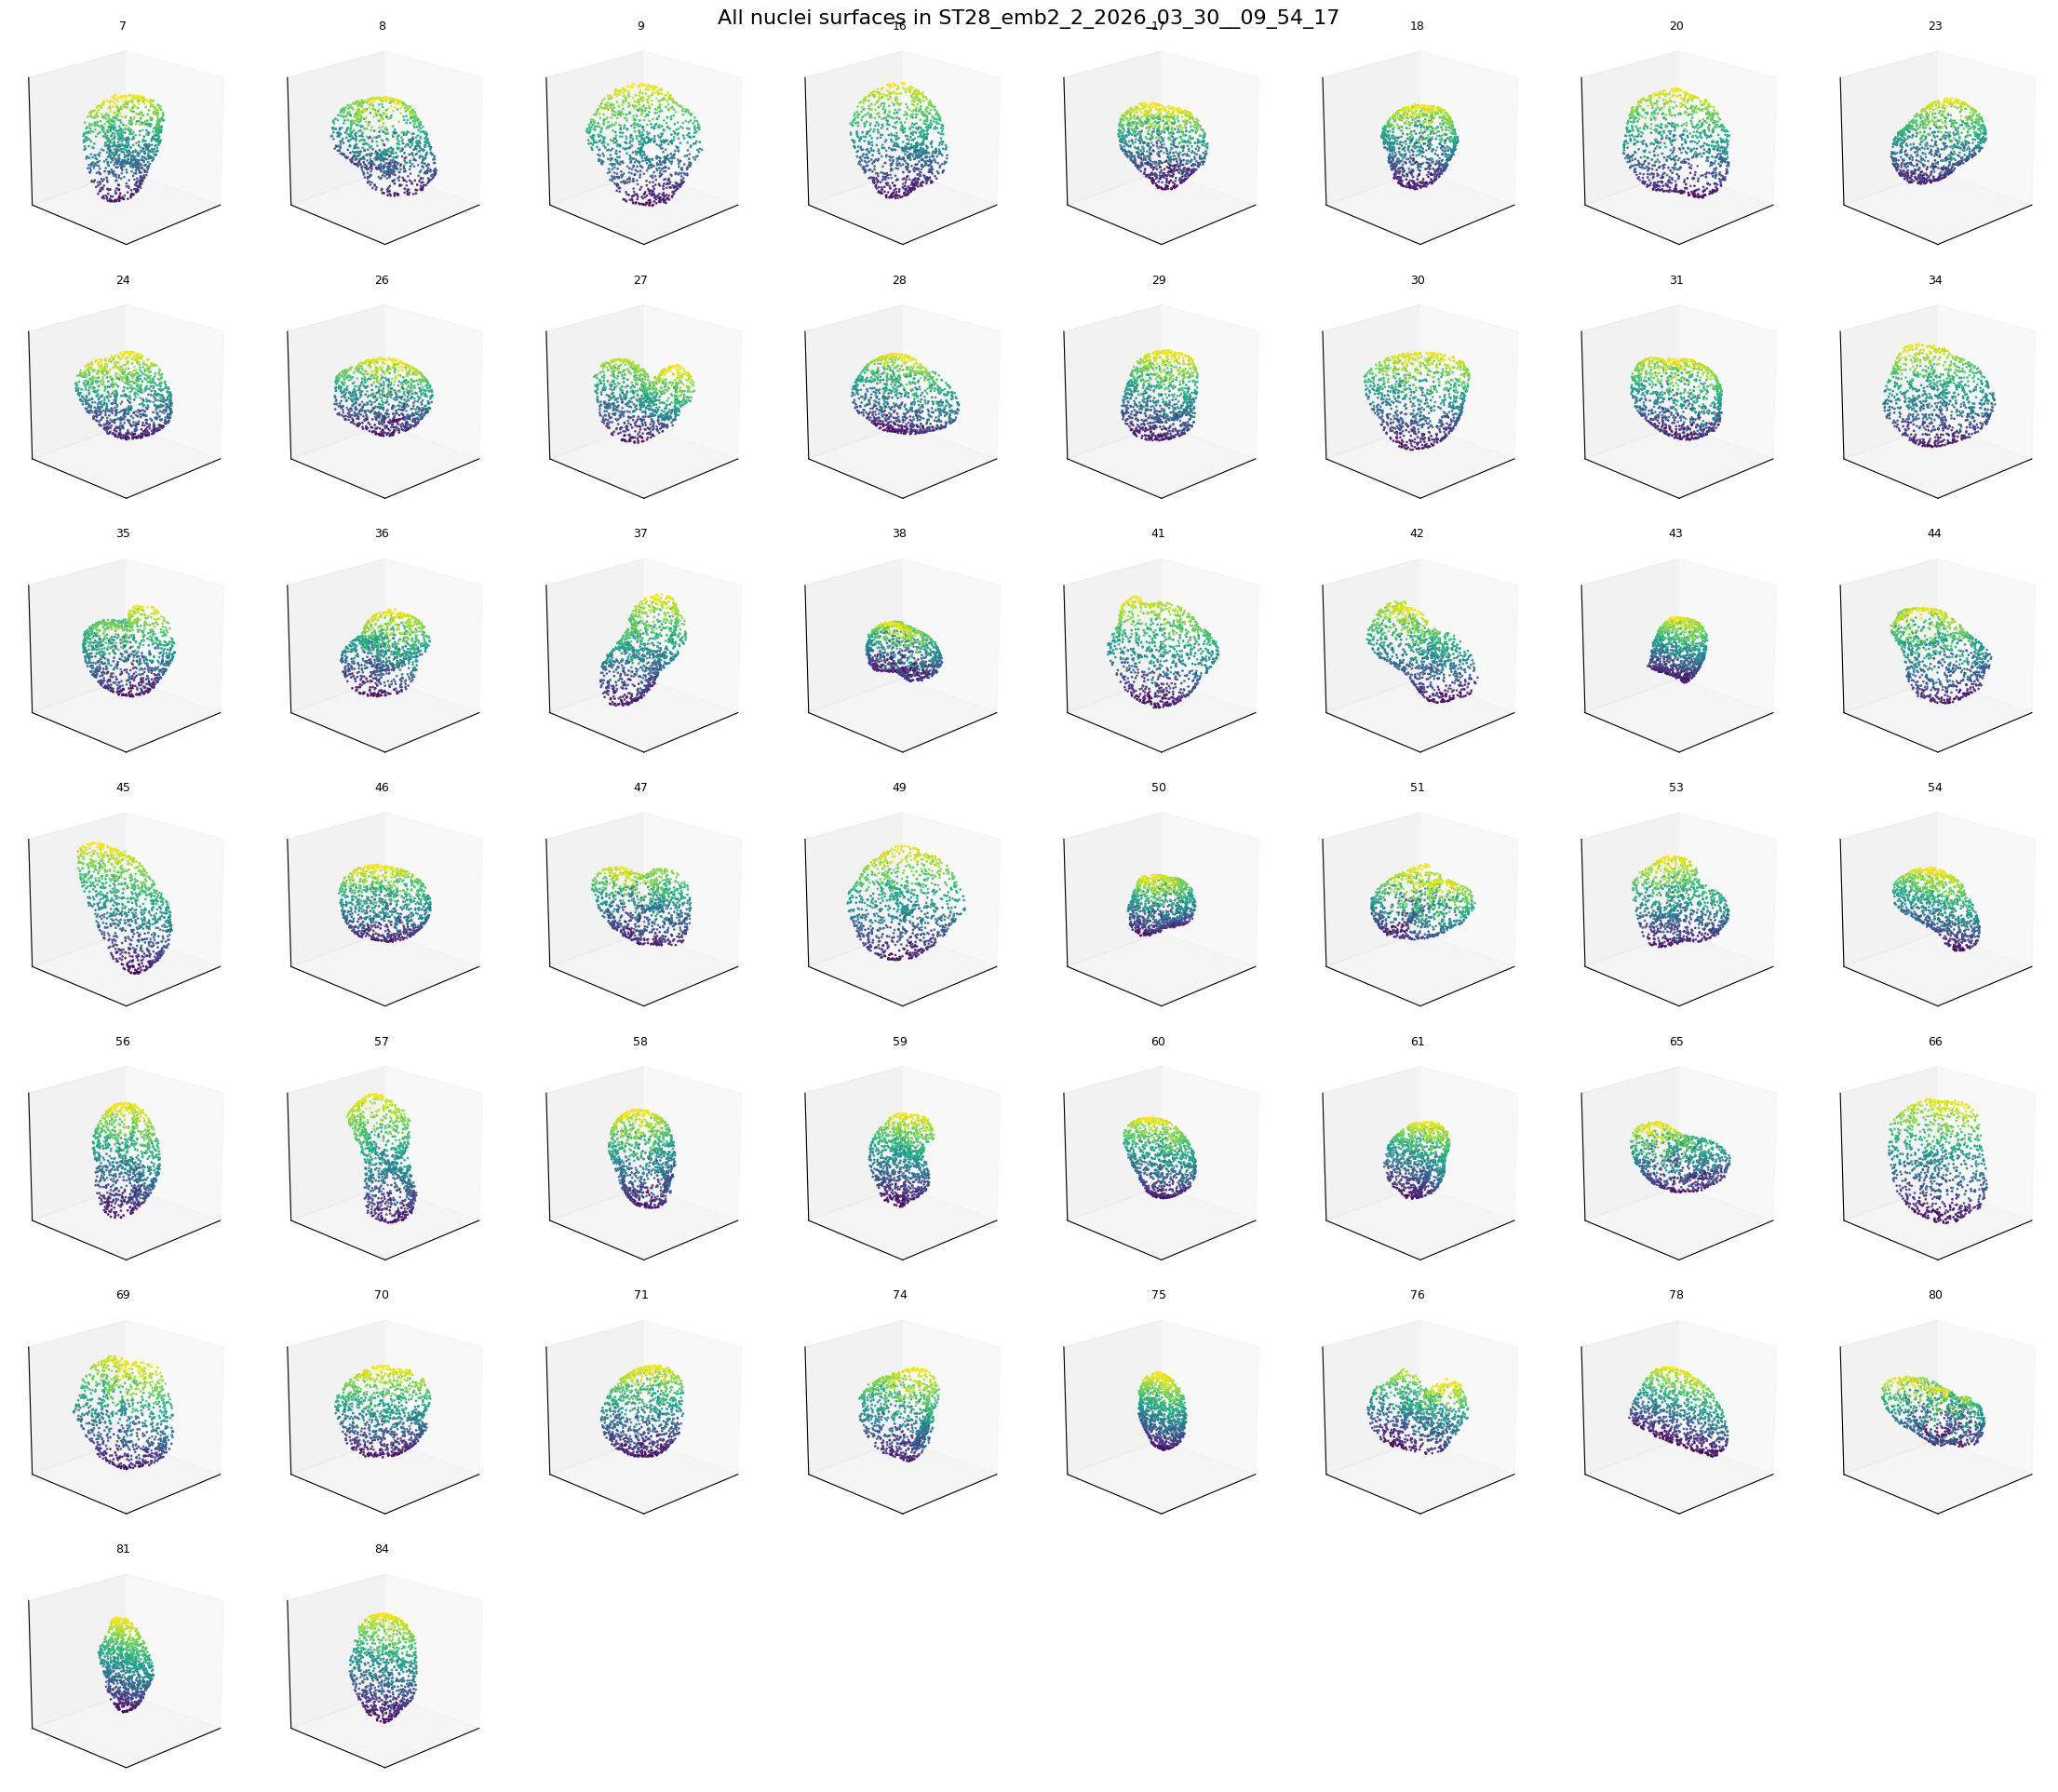

In [28]:
from pathlib import Path
import matplotlib.pyplot as plt

data_dir = Path("/insomnia001/home/hy2897/data/mcc/ST28_emb2_2_2026_03_30__09_54_17")
ply_files = sorted(
    data_dir.glob("*.ply"),
    key=lambda path: int(path.stem) if path.stem.isdigit() else path.stem,
)

all_points = []
for ply_file in ply_files:
    pcd = o3d.io.read_point_cloud(str(ply_file))
    points = np.asarray(pcd.points)
    if points.size == 0:
        continue
    all_points.append((ply_file.stem, points))

if not all_points:
    raise ValueError(f"No valid point clouds found in {data_dir}")

n_cols = 8
n_rows = int(np.ceil(len(all_points) / n_cols))
colors = plt.cm.turbo(np.linspace(0, 1, len(all_points)))
max_extent = max(np.abs(points).max() for _, points in all_points)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(2.8 * n_cols, 2.8 * n_rows),
    subplot_kw={"projection": "3d"},
)
axes = np.atleast_2d(axes)

for ax, ((name, points), color) in zip(axes.flat, zip(all_points, colors)):
    ax.scatter(points[:, 0], points[:, 1], points[:, 2], c = points[:, 2], s=1, alpha=0.8, cmap="viridis")
    ax.set_title(name, fontsize=9, pad=2)
    ax.set_xlim(-max_extent, max_extent)
    ax.set_ylim(-max_extent, max_extent)
    ax.set_zlim(-max_extent, max_extent)
    ax.set_box_aspect((1, 1, 1))
    ax.view_init(elev=20, azim=45)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.grid(False)

for ax in axes.flat[len(all_points):]:
    ax.axis("off")

fig.suptitle(f"All nuclei surfaces in {data_dir.name}", fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

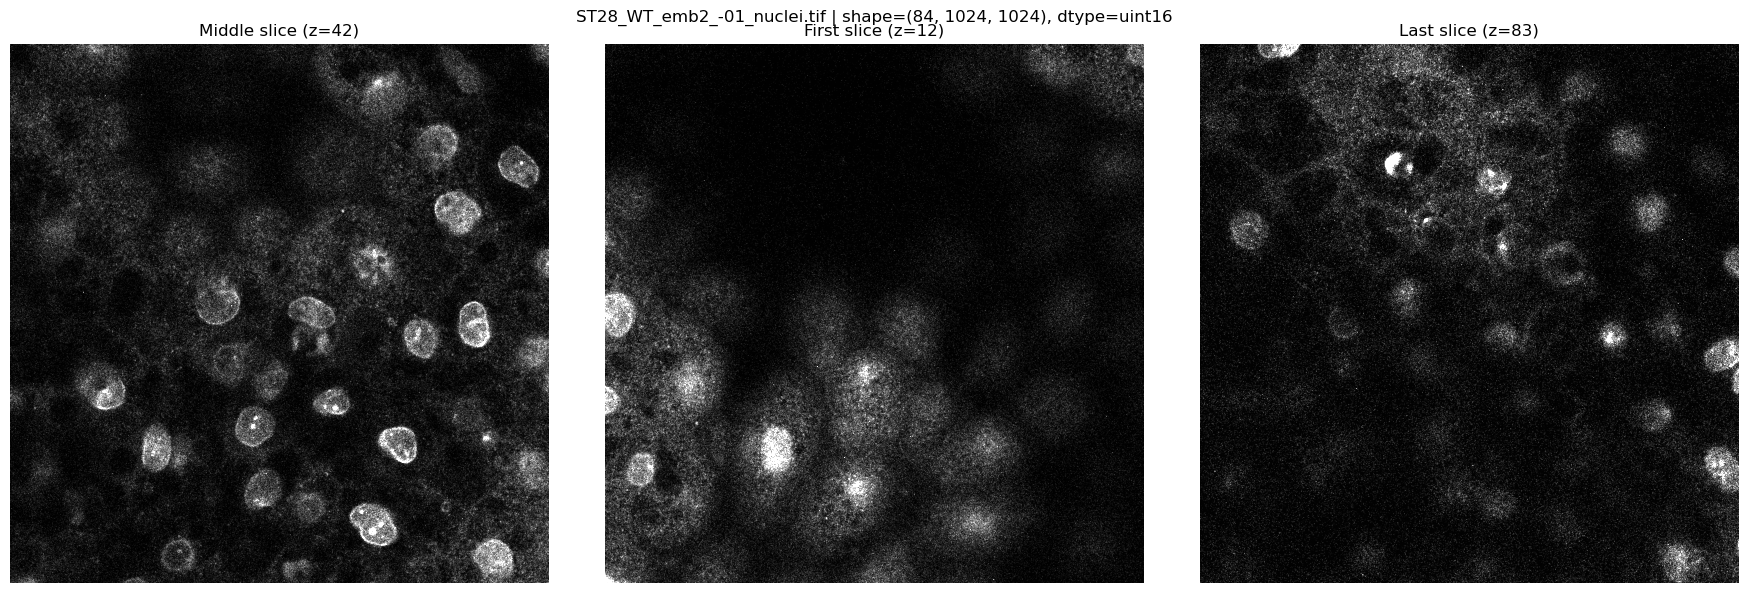

In [6]:
from pathlib import Path
import tifffile as tiff
import matplotlib.pyplot as plt
import numpy as np

tif_path = Path("/Users/hy2897/Documents/Bianca/point cloud/data/ST28_WT_emb2_-01_nuclei.tif")
stack = tiff.imread(tif_path)

z_idx = stack.shape[0] // 2
mid_slice = stack[z_idx]
first_slice = stack[12]
last_slice = stack[66]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, image, title in [
    (axes[0], mid_slice, f"Middle slice (z={z_idx})"),
    (axes[1], first_slice, f"First slice (z=12)"),
    (axes[2], last_slice, f"Last slice (z={stack.shape[0]-1})"),
]:
    vmin, vmax = np.percentile(image, [1, 99.5])
    if vmin == vmax:
        vmin, vmax = image.min(), image.max()
    ax.imshow(image, cmap="gray", vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.axis("off")

fig.suptitle(f"{tif_path.name} | shape={stack.shape}, dtype={stack.dtype}", fontsize=12)
plt.tight_layout()
plt.show()

In [1]:
import napari
from tifffile import imread, imwrite
#from cellpose import models, train
import numpy as np
from czifile import imread as czi_imread
image_path = '/insomnia001/home/hy2897/data/mcc/ST28_emb1_1_2026_03_30__09_37_06/ST28_emb1_1_2026_03_30__09_37_06.czi'
image_raw = czi_imread(image_path)
img_nuclei_raw = image_raw[0, 0, 2, 0, :, :, :,0]  # (Z, Y, X)
anno_mask = imread('/insomnia001/home/hy2897/data/mcc/ST28_emb1_1_2026_03_30__09_37_06/ST28_emb1_1_2026_03_30__09_37_06_anno.tif')
n2v_nuclei = imread('/insomnia001/home/hy2897/data/mcc/ST28_emb1_1_2026_03_30__09_37_06/ST28_emb1_1_2026_03_30__09_37_06_n2v_3d.tif')
viwer = napari.Viewer()
viwer.add_image(image_raw[0, 0, 2, 0, :, :, :,0], name='channel nuclei', colormap='magenta')
viwer.add_image(image_raw[0, 0, 0, 0, :, :, :,0], name='channel membrane', colormap='green')
viwer.add_image(image_raw[0, 0, 1, 0, :, :, :,0], name='channel cilia', colormap='yellow')
viwer.add_image(n2v_nuclei)
viwer.add_labels(anno_mask, name='annotation')

napari.run()


Available platform plugins are: eglfs, linuxfb, minimal, minimalegl, offscreen, vnc, wayland-egl, wayland, wayland-xcomposite-egl, wayland-xcomposite-glx, webgl, xcb.



: 

: 

: 